train/REAL           : 50000 images
train/FAKE           : 50000 images
test/REAL            : 10000 images
test/FAKE            : 10000 images
Loading images …
  Loaded 50000 train / 10000 test  (159.6s)


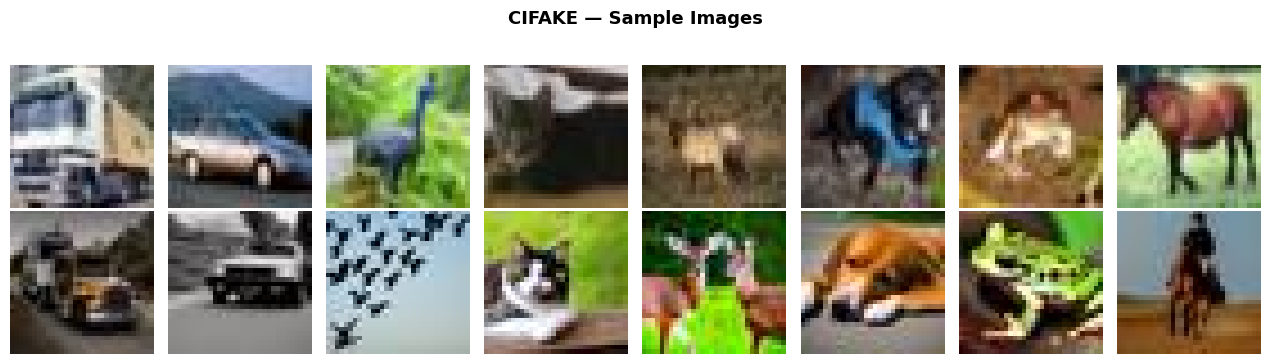

  Saved → outputs/eda_samples.png
Computing average spectra …


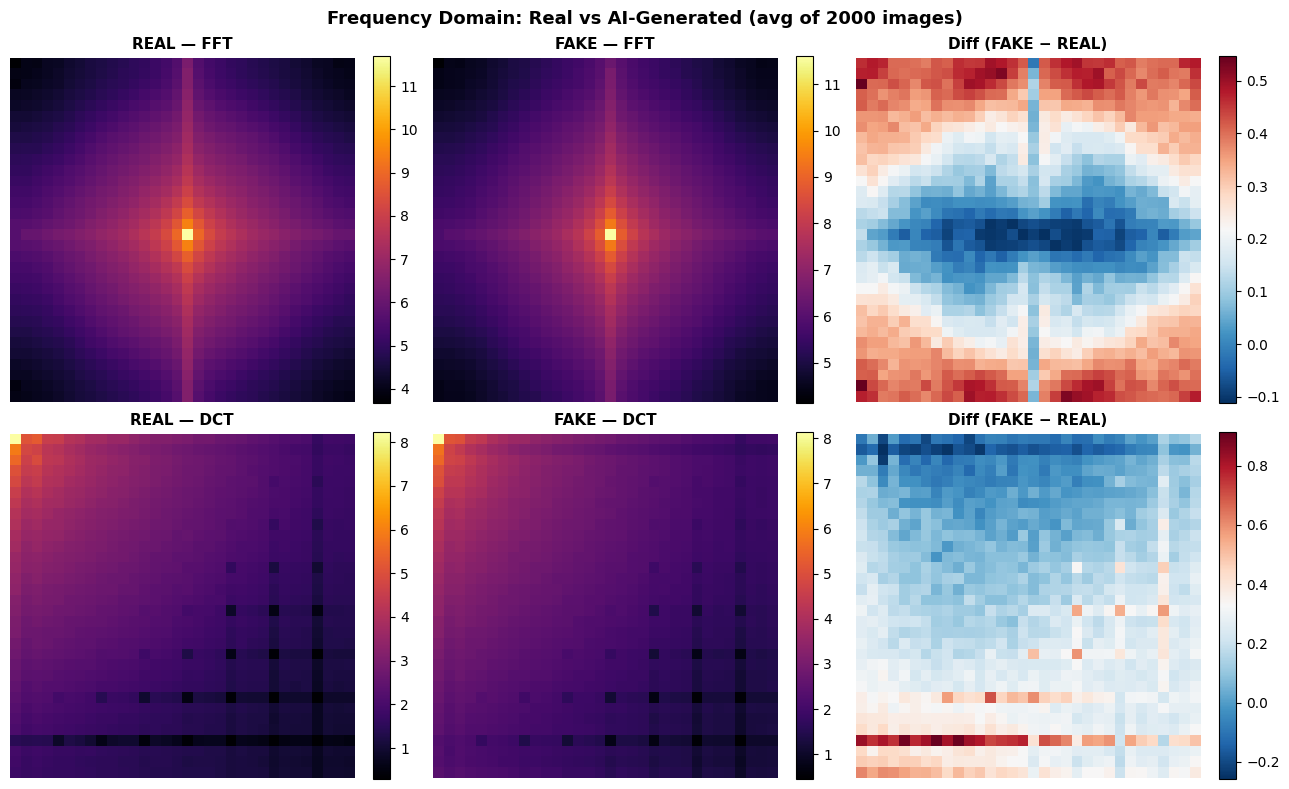


Extracting features (train) …
  Train feature matrix: (50000, 1152)  (76.8s)
Extracting features (test) …
  Test  feature matrix: (10000, 1152)   (14.9s)

── Training on clean data ──────────────────────────────
  Logistic Regression        acc=0.8282  f1=0.8288  (10.6s)
  LinearSVC                  acc=0.8283  f1=0.8290  (215.5s)
  XGBoost                    acc=0.9071  f1=0.9082  (209.3s)


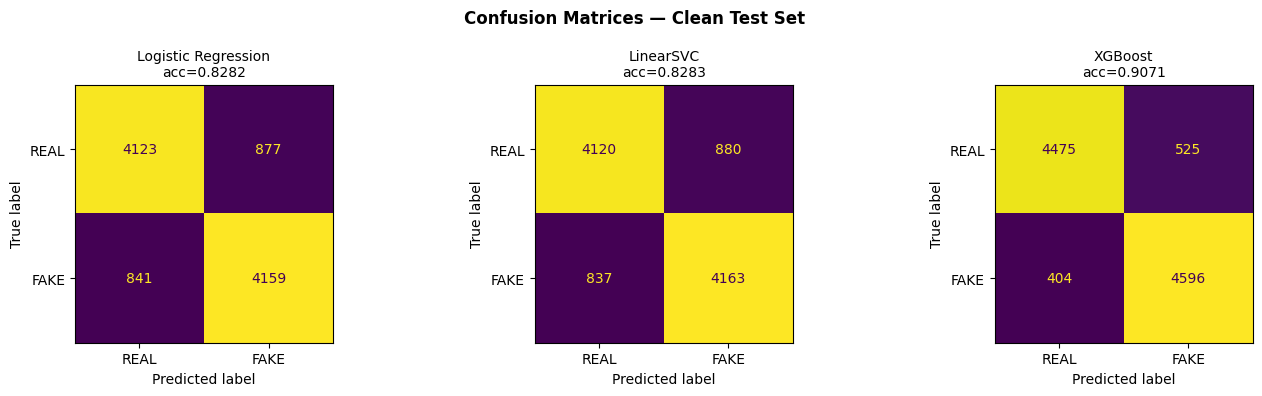


── Robustness experiments ──────────────────────────────

  JPEG quality
    q=75  Logistic Regression        acc=0.8278  drop=+0.0004
    q=75  LinearSVC                  acc=0.8276  drop=+0.0007
    q=75  XGBoost                    acc=0.9060  drop=+0.0011
    q=50  Logistic Regression        acc=0.7099  drop=+0.1183
    q=50  LinearSVC                  acc=0.7089  drop=+0.1194
    q=50  XGBoost                    acc=0.8314  drop=+0.0757
    q=25  Logistic Regression        acc=0.7443  drop=+0.0839
    q=25  LinearSVC                  acc=0.7428  drop=+0.0855
    q=25  XGBoost                    acc=0.7943  drop=+0.1128

  Gaussian blur
    σ=1  Logistic Regression        acc=0.5479  drop=+0.2803
    σ=1  LinearSVC                  acc=0.5467  drop=+0.2816
    σ=1  XGBoost                    acc=0.5422  drop=+0.3649
    σ=2  Logistic Regression        acc=0.6976  drop=+0.1306
    σ=2  LinearSVC                  acc=0.6970  drop=+0.1313
    σ=2  XGBoost                    acc=0.5831

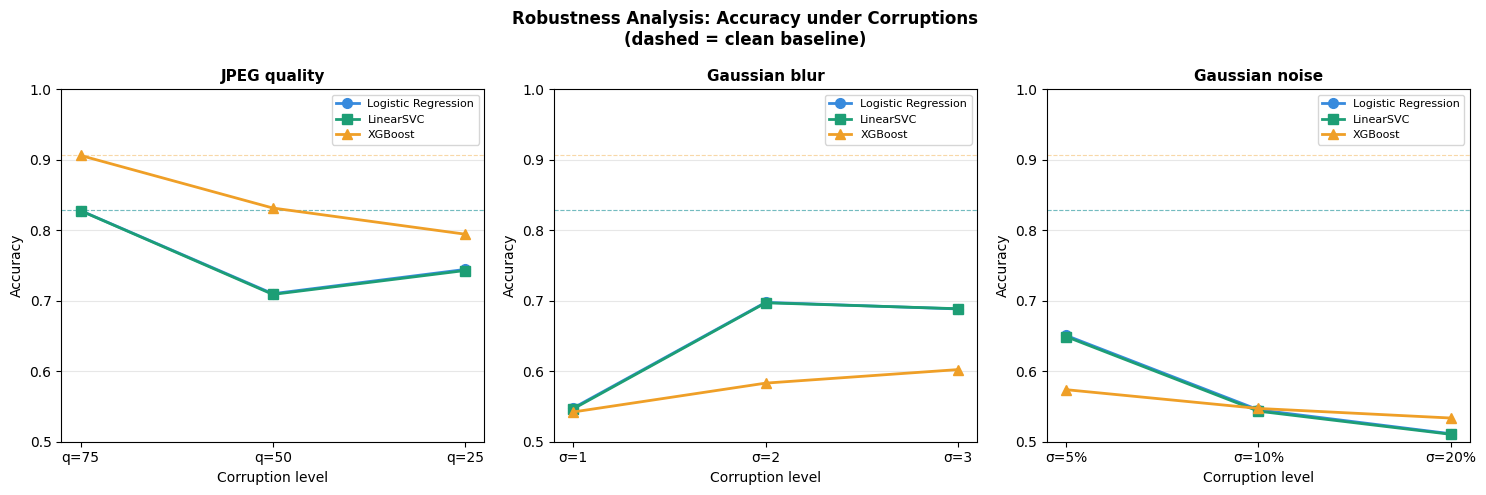

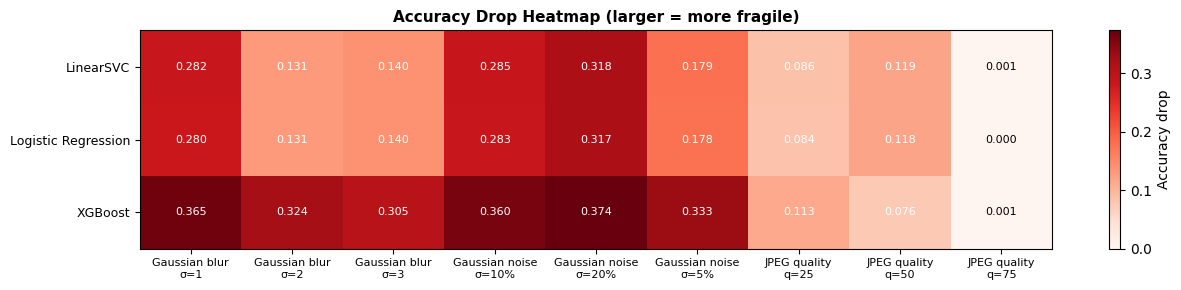


SUMMARY — Clean Test Set
  Logistic Regression        acc=0.8282  f1=0.8288
  LinearSVC                  acc=0.8283  f1=0.8290
  XGBoost                    acc=0.9071  f1=0.9082

SUMMARY — Avg accuracy drop per corruption type
------------------------------------------------------------
corruption           Gaussian blur  Gaussian noise  JPEG quality
model                                                           
LinearSVC                   0.1842          0.2607        0.0685
Logistic Regression         0.1836          0.2591        0.0675
XGBoost                     0.3312          0.3556        0.0632

All outputs saved to ./outputs/


In [14]:
# =============================================================
#  AIGC Deepfake Detection — ML Baseline Pipeline (Part 1)
#  Dataset : CIFAKE (Real vs Stable-Diffusion-generated, 32x32)
#  Features: DCT coefficients + FFT power spectrum + Color Hist
#  Models  : Logistic Regression / LinearSVC / XGBoost
#  Extra   : Robustness analysis under JPEG / Blur / Noise
# =============================================================

# ── 0. Imports ───────────────────────────────────────────────
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image, ImageFilter
from scipy.fftpack import dct
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import xgboost as xgb
warnings.filterwarnings("ignore")

# ── 1. Paths (Kaggle layout) ──────────────────────────────────
BASE = Path("/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images")

TRAIN_REAL = BASE / "train" / "REAL"
TRAIN_FAKE = BASE / "train" / "FAKE"
TEST_REAL  = BASE / "test" / "REAL"
TEST_FAKE  = BASE / "test" / "FAKE"
# 验证
for p in [TRAIN_REAL, TRAIN_FAKE, TEST_REAL, TEST_FAKE]:
    count = len(list(p.glob("*.jpg")))
    print(f"{str(p.relative_to(BASE)):<20} : {count} images")
    
# ── 2. Config ─────────────────────────────────────────────────
IMG_SIZE      = 32          # CIFAKE native resolution
N_TRAIN_EACH  = 25000       # images per class for training (50k total)
N_TEST_EACH   = 5000        # images per class for testing  (10k total)
RANDOM_STATE  = 42

# ── 3. Image loaders ──────────────────────────────────────────
def load_images(folder: Path, n: int, label: int):
    """Load n images from folder, return (imgs_list, labels_array)."""
    paths = sorted(folder.glob("*.jpg"))[:n]
    imgs, labels = [], []
    for p in paths:
        img = Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        imgs.append(np.array(img, dtype=np.uint8))
        labels.append(label)
    return imgs, np.array(labels)

print("Loading images …")
t0 = time.time()
tr_real, tr_real_y = load_images(TRAIN_REAL, N_TRAIN_EACH, 0)
tr_fake, tr_fake_y = load_images(TRAIN_FAKE, N_TRAIN_EACH, 1)
te_real, te_real_y = load_images(TEST_REAL,  N_TEST_EACH,  0)
te_fake, te_fake_y = load_images(TEST_FAKE,  N_TEST_EACH,  1)

X_train_imgs = tr_real + tr_fake
y_train       = np.concatenate([tr_real_y, tr_fake_y])
X_test_imgs   = te_real + te_fake
y_test        = np.concatenate([te_real_y, te_fake_y])
print(f"  Loaded {len(X_train_imgs)} train / {len(X_test_imgs)} test  ({time.time()-t0:.1f}s)")

# ── 4. EDA ────────────────────────────────────────────────────
def plot_samples(real_imgs, fake_imgs, n=8, save="outputs/eda_samples.png"):
    fig, axes = plt.subplots(2, n, figsize=(n * 1.6, 3.6))
    for i in range(n):
        axes[0, i].imshow(real_imgs[i]);  axes[0, i].axis("off")
        axes[1, i].imshow(fake_imgs[i]);  axes[1, i].axis("off")
    axes[0, 0].set_ylabel("REAL", fontsize=11, fontweight="bold")
    axes[1, 0].set_ylabel("FAKE", fontsize=11, fontweight="bold")
    plt.suptitle("CIFAKE — Sample Images", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved → {save}")

plot_samples(tr_real[:8], tr_fake[:8])

# ── 5. Frequency Spectrum Visualisation ───────────────────────
def avg_spectrum(imgs, mode="fft"):
    """Compute average log-magnitude spectrum across a list of RGB images."""
    spectra = []
    for img in imgs:
        gray = np.mean(img, axis=2)          # RGB → grayscale
        if mode == "fft":
            f   = np.fft.fft2(gray)
            f   = np.fft.fftshift(f)
            sp  = np.log1p(np.abs(f))
        else:                                 # dct
            sp  = np.log1p(np.abs(dct(dct(gray.T, norm="ortho").T, norm="ortho")))
        spectra.append(sp)
    return np.mean(spectra, axis=0)

print("Computing average spectra …")
fft_real = avg_spectrum(tr_real[:2000], "fft")
fft_fake = avg_spectrum(tr_fake[:2000], "fft")
dct_real = avg_spectrum(tr_real[:2000], "dct")
dct_fake = avg_spectrum(tr_fake[:2000], "dct")

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
titles = [["REAL — FFT", "FAKE — FFT", "Diff (FAKE − REAL)"],
          ["REAL — DCT", "FAKE — DCT", "Diff (FAKE − REAL)"]]
maps   = [fft_real, fft_fake, fft_fake - fft_real,
          dct_real, dct_fake, dct_fake - dct_real]
cmaps  = ["inferno", "inferno", "RdBu_r",
          "inferno", "inferno", "RdBu_r"]
for i, ax in enumerate(axes.flat):
    im = ax.imshow(maps[i], cmap=cmaps[i]); plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(titles[i // 3][i % 3], fontsize=11, fontweight="bold")
    ax.axis("off")
plt.suptitle("Frequency Domain: Real vs AI-Generated (avg of 2000 images)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/freq_spectrum.png", dpi=150, bbox_inches="tight"); plt.show()

# ── 6. Feature Extraction ─────────────────────────────────────
def extract_dct_features(img: np.ndarray) -> np.ndarray:
    """
    2-D DCT on grayscale image.
    Returns flattened 1024-dim vector (all coefficients).
    High-frequency bins carry the GAN/diffusion artifacts.
    """
    gray = np.mean(img, axis=2).astype(np.float32) / 255.0
    d    = dct(dct(gray.T, norm="ortho").T, norm="ortho")
    return d.flatten()                          # 32*32 = 1024

def extract_fft_features(img: np.ndarray) -> np.ndarray:
    """
    Log-magnitude FFT spectrum → 64 radial-frequency bin statistics.
    Captures ring-averaged power at each spatial frequency.
    """
    gray   = np.mean(img, axis=2).astype(np.float32) / 255.0
    f      = np.fft.fftshift(np.fft.fft2(gray))
    mag    = np.log1p(np.abs(f))
    cy, cx = IMG_SIZE // 2, IMG_SIZE // 2
    y, x   = np.ogrid[:IMG_SIZE, :IMG_SIZE]
    radius = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(int)
    n_bins = IMG_SIZE // 2
    feats  = np.zeros(n_bins * 2)
    for r in range(n_bins):
        mask = radius == r
        vals = mag[mask]
        if len(vals):
            feats[r]          = vals.mean()
            feats[r + n_bins] = vals.std()
    return feats                                # 16 bins × 2 stats = 32

def extract_color_hist(img: np.ndarray, bins=32) -> np.ndarray:
    """Per-channel colour histogram (96 dims)."""
    feats = []
    for c in range(3):
        h, _ = np.histogram(img[:, :, c], bins=bins, range=(0, 256))
        feats.append(h / h.sum())
    return np.concatenate(feats)                # 3 × 32 = 96

def extract_features(imgs: list) -> np.ndarray:
    """Combine DCT + FFT + colour histogram for a list of images."""
    rows = []
    for img in imgs:
        dct_f  = extract_dct_features(img)     # 1024
        fft_f  = extract_fft_features(img)     #   64
        col_f  = extract_color_hist(img)        #   96
        rows.append(np.concatenate([dct_f, fft_f, col_f]))
    return np.array(rows, dtype=np.float32)     # N × 1152 (1024+32+96)

print("\nExtracting features (train) …")
t0 = time.time()
X_train = extract_features(X_train_imgs)
print(f"  Train feature matrix: {X_train.shape}  ({time.time()-t0:.1f}s)")

print("Extracting features (test) …")
t0 = time.time()
X_test = extract_features(X_test_imgs)
print(f"  Test  feature matrix: {X_test.shape}   ({time.time()-t0:.1f}s)")

# ── 7. ML Models ──────────────────────────────────────────────
MODELS = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000, C=1.0,
                                      random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "LinearSVC": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    CalibratedClassifierCV(LinearSVC(max_iter=2000, C=1.0,
                                                    random_state=RANDOM_STATE)))
    ]),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ),
}

results_clean = {}
print("\n── Training on clean data ──────────────────────────────")
for name, model in MODELS.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    f1    = f1_score(y_test, preds)
    results_clean[name] = {"acc": acc, "f1": f1}
    print(f"  {name:<25}  acc={acc:.4f}  f1={f1:.4f}  ({time.time()-t0:.1f}s)")

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, MODELS.items()):
    preds = model.predict(X_test)
    cm    = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["REAL", "FAKE"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nacc={results_clean[name]['acc']:.4f}", fontsize=10)
plt.suptitle("Confusion Matrices — Clean Test Set", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/confusion_matrices_clean.png", dpi=150, bbox_inches="tight"); plt.show()

# ── 8. Robustness Experiments ────────────────────────────────
def corrupt_jpeg(imgs: list, quality: int) -> list:
    """Re-encode images with JPEG compression at given quality."""
    out = []
    for arr in imgs:
        img  = Image.fromarray(arr)
        buf  = __import__("io").BytesIO()
        img.save(buf, "JPEG", quality=quality)
        buf.seek(0)
        out.append(np.array(Image.open(buf).convert("RGB")))
    return out

def corrupt_blur(imgs: list, sigma: float) -> list:
    """Apply Gaussian blur."""
    out = []
    for arr in imgs:
        blurred = Image.fromarray(arr).filter(
            ImageFilter.GaussianBlur(radius=sigma))
        out.append(np.array(blurred))
    return out

def corrupt_noise(imgs: list, std: float) -> list:
    """Add Gaussian noise (pixel values clipped to [0,255])."""
    out = []
    for arr in imgs:
        noise  = np.random.normal(0, std * 255, arr.shape)
        noisy  = np.clip(arr.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        out.append(noisy)
    return out

CORRUPTIONS = {
    "JPEG quality":   [(corrupt_jpeg,  q)   for q in [75, 50, 25]],
    "Gaussian blur":  [(corrupt_blur,  s)   for s in [1,  2,  3]],
    "Gaussian noise": [(corrupt_noise, std) for std in [0.05, 0.10, 0.20]],
}
PARAM_LABELS = {
    "JPEG quality":   ["q=75", "q=50", "q=25"],
    "Gaussian blur":  ["σ=1",  "σ=2",  "σ=3"],
    "Gaussian noise": ["σ=5%", "σ=10%","σ=20%"],
}

# Evaluate one corruption level, return {model_name: acc}
def eval_corruption(corrupt_fn, param, models, y_true):
    imgs_c = corrupt_fn(X_test_imgs, param)
    X_c    = extract_features(imgs_c)
    return {name: accuracy_score(y_true, m.predict(X_c))
            for name, m in models.items()}

# Run all corruptions
robustness_records = []  # [{corruption, level, model, acc}]
print("\n── Robustness experiments ──────────────────────────────")
for c_name, levels in CORRUPTIONS.items():
    clean_accs = {n: results_clean[n]["acc"] for n in MODELS}
    print(f"\n  {c_name}")
    for (fn, param), label in zip(levels, PARAM_LABELS[c_name]):
        accs = eval_corruption(fn, param, MODELS, y_test)
        for model_name, acc in accs.items():
            drop = clean_accs[model_name] - acc
            robustness_records.append({
                "corruption": c_name, "level": label,
                "model": model_name, "acc": acc, "drop": drop
            })
            print(f"    {label}  {model_name:<25}  acc={acc:.4f}  drop={drop:+.4f}")

df_rob = pd.DataFrame(robustness_records)
df_rob.to_csv("outputs/robustness_results.csv", index=False)
print("\n  Saved → outputs/robustness_results.csv")

# ── 9. Robustness Visualisation ──────────────────────────────
COLORS = {
    "Logistic Regression": "#378ADD",
    "LinearSVC":           "#1D9E75",
    "XGBoost":             "#EF9F27",
}
MARKERS = {"Logistic Regression": "o", "LinearSVC": "s", "XGBoost": "^"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, c_name in zip(axes, CORRUPTIONS.keys()):
    labels = PARAM_LABELS[c_name]
    for model_name in MODELS:
        sub  = df_rob[(df_rob.corruption == c_name) & (df_rob.model == model_name)]
        accs = sub.set_index("level").loc[labels, "acc"].values
        base = results_clean[model_name]["acc"]
        ax.axhline(base, color=COLORS[model_name], lw=0.8, ls="--", alpha=0.4)
        ax.plot(labels, accs,
                color=COLORS[model_name], marker=MARKERS[model_name],
                lw=2, markersize=7, label=model_name)
    ax.set_title(c_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Corruption level")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.5, 1.0)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Robustness Analysis: Accuracy under Corruptions\n(dashed = clean baseline)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/robustness_curves.png", dpi=150, bbox_inches="tight"); plt.show()

# ── 10. Accuracy-drop heatmap ────────────────────────────────
pivot = df_rob.pivot_table(index="model", columns=["corruption", "level"], values="drop")
fig, ax = plt.subplots(figsize=(13, 3))
im = ax.imshow(pivot.values, cmap="Reds", aspect="auto", vmin=0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c}\n{l}" for c, l in pivot.columns], fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}",
                ha="center", va="center", fontsize=8,
                color="white" if pivot.values[i,j] > 0.05 else "black")
plt.colorbar(im, ax=ax, label="Accuracy drop")
ax.set_title("Accuracy Drop Heatmap (larger = more fragile)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/drop_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# ── 11. Summary Table ─────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY — Clean Test Set")
print("="*60)
for name, r in results_clean.items():
    print(f"  {name:<25}  acc={r['acc']:.4f}  f1={r['f1']:.4f}")

print("\nSUMMARY — Avg accuracy drop per corruption type")
print("-"*60)
avg_drop = df_rob.groupby(["model", "corruption"])["drop"].mean().unstack()
print(avg_drop.round(4).to_string())

print("\nAll outputs saved to ./outputs/")